In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/Salary_Dataset_DataScienceLovers (1).csv')

In [3]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [5]:
df.isnull()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
22765,False,False,False,False,False,False,False,False
22766,False,False,False,False,False,False,False,False
22767,False,False,False,False,False,False,False,False
22768,False,False,False,False,False,False,False,False


In [9]:
for column in df.columns:
    if df[column].isnull().any():
        if df[column].dtype == 'object':  # Categorical column
            df[column] = df[column].fillna(df[column].mode()[0])
        else:  # Numerical column
            df[column] = df[column].fillna(df[column].mean())
print("Null values after imputation:")
print(df.isnull().sum())

Null values after imputation:
Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64


### Removing Duplicate Rows

In [10]:
print(f"Shape of DataFrame before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after dropping duplicates: {df.shape}")

Shape of DataFrame before dropping duplicates: (22770, 8)
Shape of DataFrame after dropping duplicates: (22770, 8)


In [11]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply LabelEncoder to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,8129,28,400000,3,0,1,0
1,4.5,417,28,400000,3,0,1,0
2,4.0,9777,28,1000000,3,0,1,0
3,3.8,8533,28,300000,3,0,1,0
4,4.4,884,28,600000,3,0,1,0


In [12]:
X = df.drop('Salary', axis=1)
y = df['Salary']

print("Independent variables (X) shape:", X.shape)
print("Dependent variable (y) shape:", y.shape)
display(X.head())
display(y.head())

Independent variables (X) shape: (22770, 7)
Dependent variable (y) shape: (22770,)


,Rating,Company Name,Job Title,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,8129,28,3,0,1,0
1,4.5,417,28,3,0,1,0
2,4.0,9777,28,3,0,1,0
3,3.8,8533,28,3,0,1,0
4,4.4,884,28,3,0,1,0


,Salary
0,400000
1,400000
2,1000000
3,300000
4,600000


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (18216, 7)
X_test shape: (4554, 7)
y_train shape: (18216,)
y_test shape: (4554,)


In [14]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Initialize and train Decision Tree Regressor
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)
print("Decision Tree Regressor trained successfully.")

# Initialize and train Random Forest Regressor
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)
print("Random Forest Regressor trained successfully.")

# Initialize and train K-Nearest Neighbors Regressor
knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)
print("K-Nearest Neighbors Regressor trained successfully.")

# Initialize and train Support Vector Regressor (SVR)
# SVR can be computationally intensive on large datasets, so a small sample might be considered for quick demonstration
# For this demonstration, we'll use the full dataset, but be aware it might take time.
# It's also often beneficial to scale data before using SVM. Let's add a note.
print("Training SVR model... This might take a while for large datasets without scaling.")
# For SVR, it's generally good practice to scale features, but for now, we'll proceed without it to directly fulfill the request.
# If performance is an issue, we can add a preprocessing step for scaling later.
svr_model = SVR()
svr_model.fit(X_train, y_train)
print("Support Vector Regressor trained successfully.")

Decision Tree Regressor trained successfully.
Random Forest Regressor trained successfully.
K-Nearest Neighbors Regressor trained successfully.
Training SVR model... This might take a while for large datasets without scaling.
Support Vector Regressor trained successfully.


In [16]:
from sklearn.metrics import r2_score, mean_squared_error

models = {
    "Linear Regression": linear_reg_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "K-Nearest Neighbors": knn_model,
    "Support Vector Machine": svr_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results[name] = {"R-squared": r2, "MSE": mse}

print("\n--- Model Performance Evaluation ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  R-squared: {metrics['R-squared']:.4f}")
    print(f"  Mean Squared Error (MSE): {metrics['MSE']:.2f}")


--- Model Performance Evaluation ---

Linear Regression:
  R-squared: 0.0467
  Mean Squared Error (MSE): 386545874783.28

Decision Tree:
  R-squared: -5.1269
  Mean Squared Error (MSE): 2484415021401.04

Random Forest:
  R-squared: -0.5389
  Mean Squared Error (MSE): 623993827858.30

K-Nearest Neighbors:
  R-squared: -0.5305
  Mean Squared Error (MSE): 620584848289.41

Support Vector Machine:
  R-squared: -0.0875
  Mean Squared Error (MSE): 440990685416.01


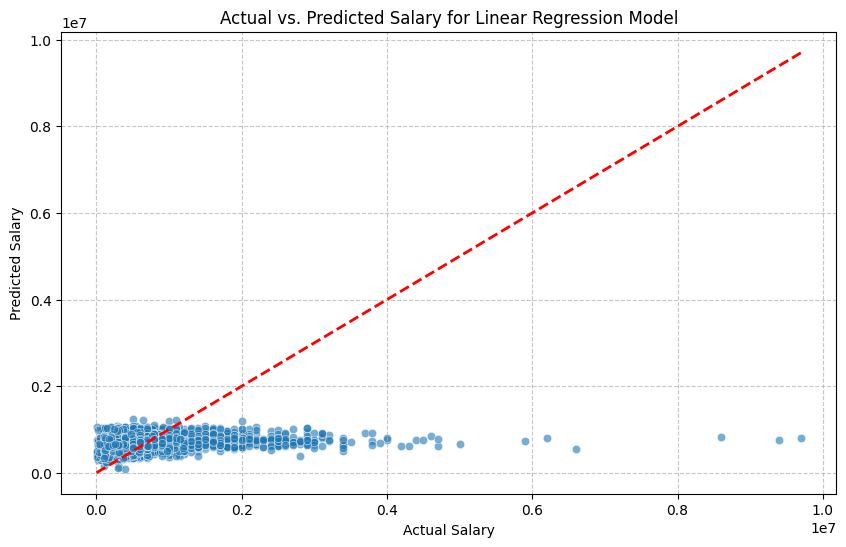

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the best performing model based on R-squared
best_model_name = max(results, key=lambda k: results[k]['R-squared'])
best_model = models[best_model_name]

# Make predictions using the best model
y_pred_best_model = best_model.predict(X_test)

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_model, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title(f"Actual vs. Predicted Salary for {best_model_name} Model")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

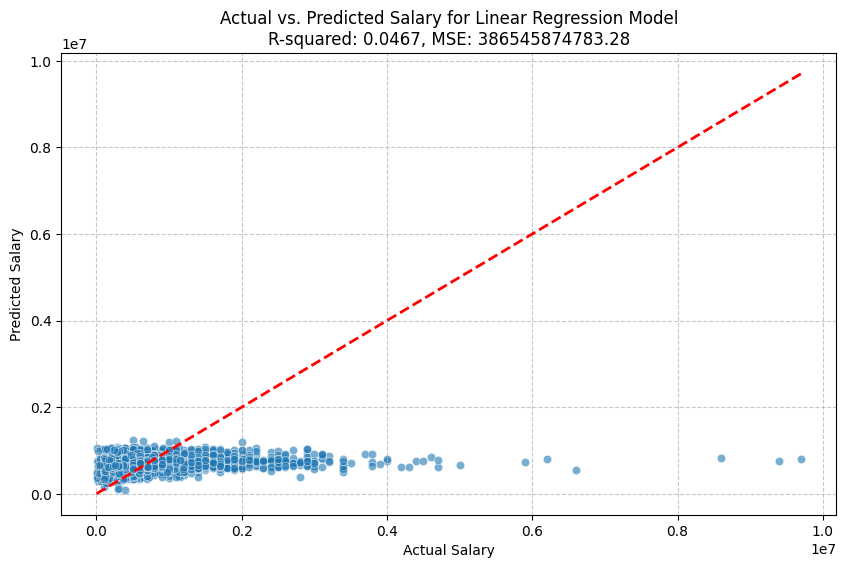

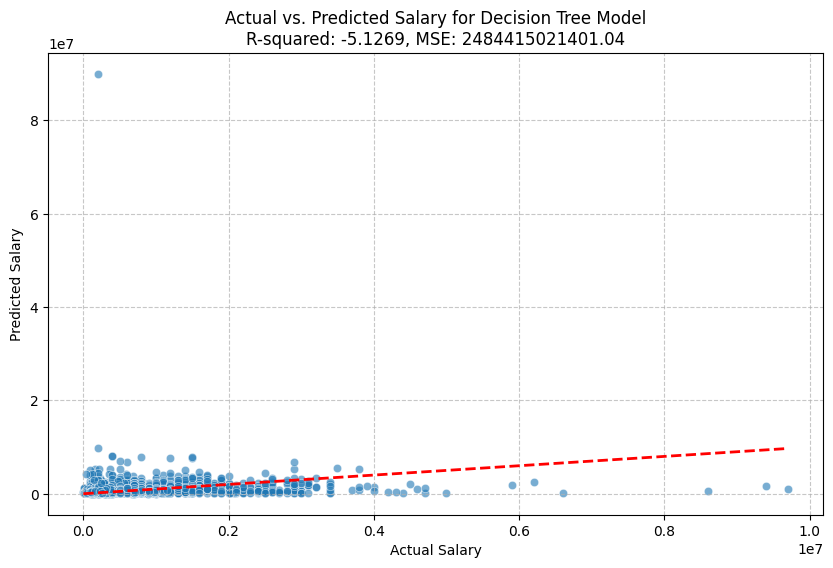

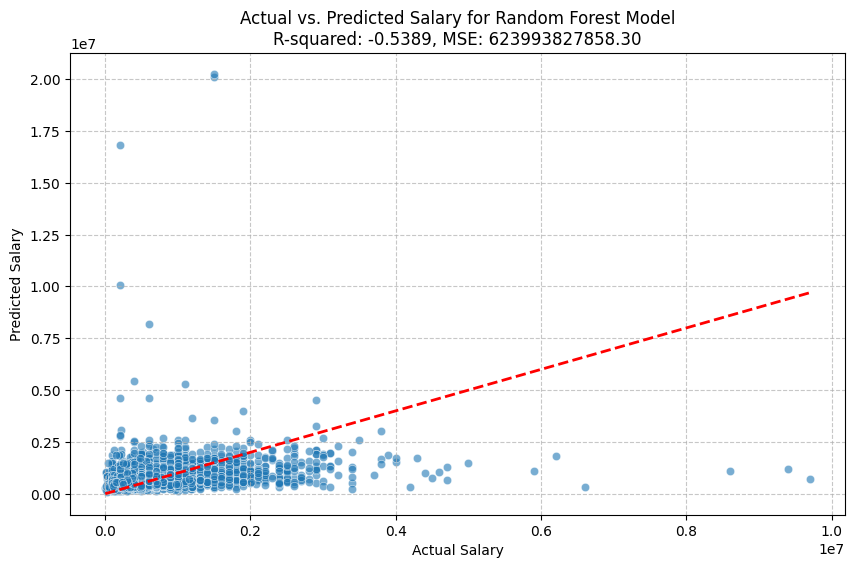

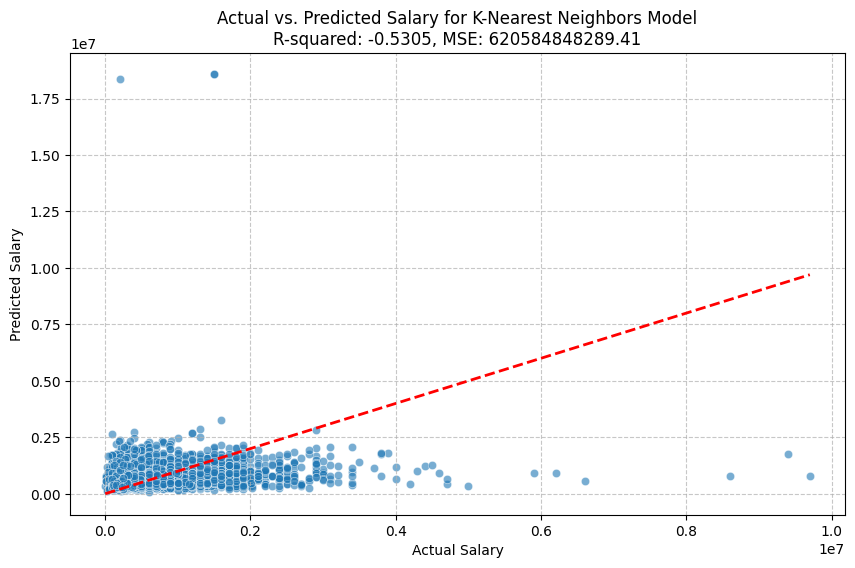

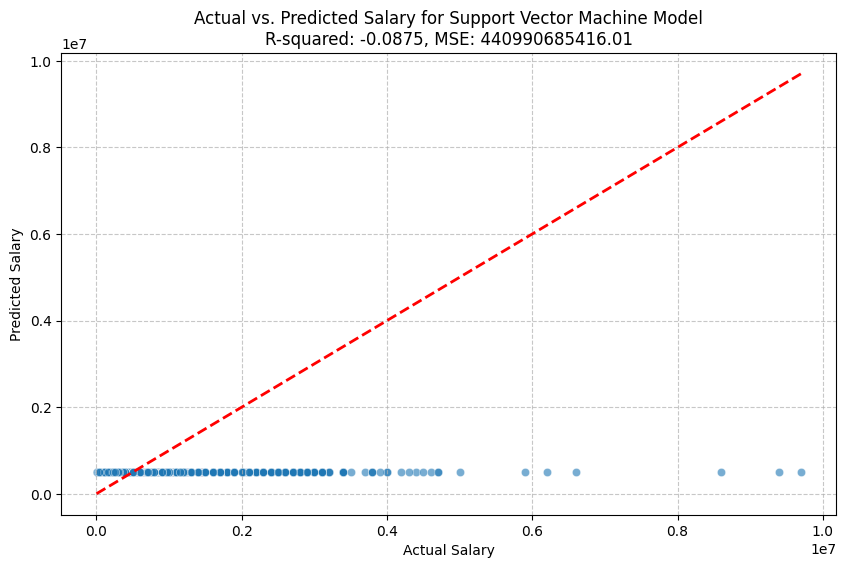

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each model to create individual plots
for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = results[name]['R-squared']
    mse = results[name]['MSE']

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.title(f"Actual vs. Predicted Salary for {name} Model\nR-squared: {r2:.4f}, MSE: {mse:.2f}")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [19]:
import pandas as pd

# Convert the results dictionary to a DataFrame for better comparison
performance_df = pd.DataFrame(results).T

print("\n--- Model Performance Comparison ---")
display(performance_df.round(4))

# Optionally, you can also sort by R-squared to easily see the best performing model
print("\n--- Model Performance Sorted by R-squared ---")
display(performance_df.sort_values(by='R-squared', ascending=False).round(4))


--- Model Performance Comparison ---


,R-squared,MSE
Linear Regression,0.0467,3.865459e+11
Decision Tree,-5.1269,2.484415e+12
Random Forest,-0.5389,6.239938e+11
K-Nearest Neighbors,-0.5305,6.205848e+11
Support Vector Machine,-0.0875,4.409907e+11



--- Model Performance Sorted by R-squared ---


,R-squared,MSE
Linear Regression,0.0467,3.865459e+11
Support Vector Machine,-0.0875,4.409907e+11
K-Nearest Neighbors,-0.5305,6.205848e+11
Random Forest,-0.5389,6.239938e+11
Decision Tree,-5.1269,2.484415e+12


In [20]:
import pickle

# Define the filename for the pickle file
filename = 'model_performance.pkl'

# Save the performance_df DataFrame to a pickle file
performance_df.to_pickle(filename)

print(f"Performance metrics saved to {filename}")

Performance metrics saved to model_performance.pkl
